<a href="https://colab.research.google.com/github/GabrielVCB/Miniprojeto-IA-PlantDisease/blob/main/MiniProjeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install kaggle

In [5]:
import os

# Substitua pelo SEU token que aparece na imagem
os.environ['KAGGLE_USERNAME'] = "gabrielveracruz7"
os.environ['KAGGLE_KEY'] = "KGAT_b61a6f8a75885678546732f8426bc221"

In [6]:
# Cria uma pasta para o projeto
!mkdir -p plant_disease_data

# Baixa o dataset (New Plant Diseases Dataset)
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p plant_disease_data --unzip

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
100% 2.70G/2.70G [02:40<00:00, 18.1MB/s]



In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configura o Data Augmentation (Requisito do miniprojeto)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Carrega os dados da pasta baixada
train_generator = train_datagen.flow_from_directory(
    'plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    target_size=(224, 224), # Resolução padrão das CNNs
    batch_size=32,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.


In [8]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras import layers, models

# Carrega modelo base com pesos gratuitos do ImageNet
base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Congela para treino rápido inicial

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5), # Regularização exigida
    layers.Dense(38, activation='softmax') # 38 classes de doenças
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configuramos os geradores apenas com o reescalonamento dos pixels (sem cortes)
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

# 2. Criamos o gerador de TREINO usando 100% das imagens da pasta 'train'
train_generator = train_datagen.flow_from_directory(
    'plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# 3. Criamos o gerador de VALIDAÇÃO usando 100% das imagens da pasta 'valid'
validation_generator = valid_datagen.flow_from_directory(
    'plant_disease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [10]:
import tensorflow as tf

# ==========================================
# FASE 1: Aquecimento (Transfer Learning)
# ==========================================
print("--- INICIANDO FASE 1: AQUECIMENTO ---")
# Garantindo que a base está congelada para o aquecimento
base_model.trainable = False
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Treino rápido de 3 épocas apenas para estabilizar a última camada
history_fase1 = model.fit(train_generator, epochs=3, validation_data=validation_generator)

# ==========================================
# FASE 2: Ajuste Fino (Fine-Tuning)
# ==========================================
print("\n--- INICIANDO FASE 2: FINE-TUNING ---")
# Destravamos a rede inteira para aprender os detalhes das folhas
base_model.trainable = True

# Recompilamos com uma taxa de aprendizado menor (1e-4) para ajustes delicados
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Treinamos por mais 5 épocas (a rede inteira aprendendo)
history_fase2 = model.fit(train_generator, epochs=5, validation_data=validation_generator)

print("\n--- TREINAMENTO CONCLUÍDO COM SUCESSO! ---")

--- INICIANDO FASE 1: AQUECIMENTO ---
Epoch 1/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 381s 148ms/step - accuracy: 0.0274 - loss: 3.6394 - val_accuracy: 0.0286 - val_loss: 3.6361
Epoch 2/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 268s 122ms/step - accuracy: 0.0282 - loss: 3.6364 - val_accuracy: 0.0286 - val_loss: 3.6360
Epoch 3/3
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 266s 121ms/step - accuracy: 0.0275 - loss: 3.6364 - val_accuracy: 0.0286 - val_loss: 3.6361

--- INICIANDO FASE 2: FINE-TUNING ---
Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1105s 432ms/step - accuracy: 0.8993 - loss: 0.3833 - val_accuracy: 0.4455 - val_loss: 2.2894
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 848s 386ms/step - accuracy: 0.9872 - loss: 0.0412 - val_accuracy: 0.8819 - val_loss: 0.4100
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 850s 387ms/step - accuracy: 0.9923 - loss: 0.0262 - val_accuracy: 0.8591 - val_loss: 0.5435
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 848s 386ms/step - accuracy: 0.9947 - loss: 0.0181 - val_accuracy: 0.4068 - val_loss

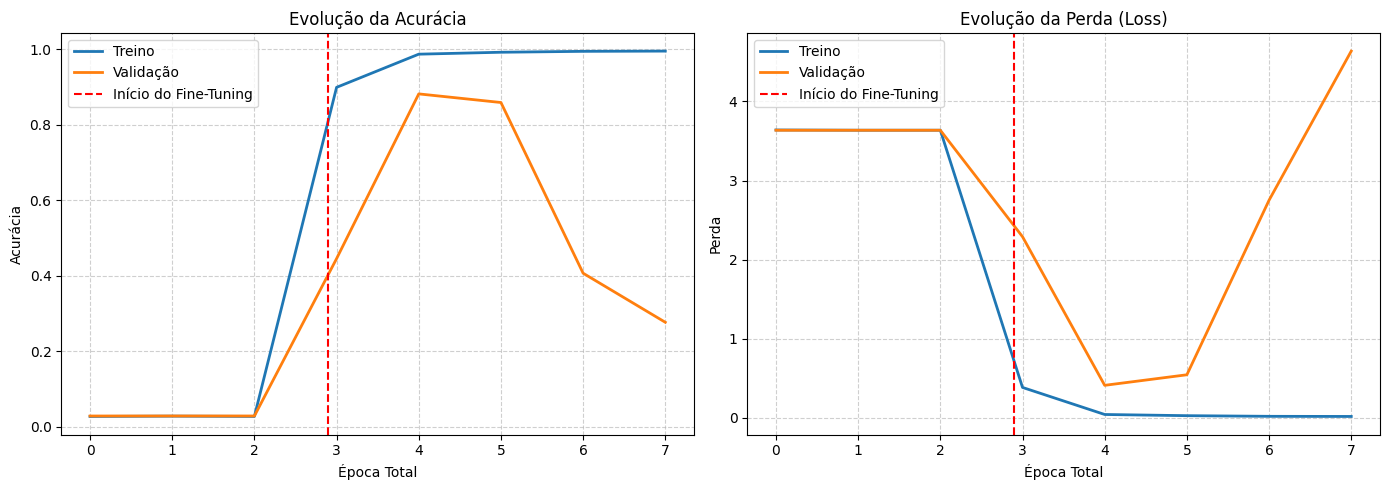

In [11]:
import matplotlib.pyplot as plt

# Juntamos os históricos das duas fases para o gráfico mostrar a evolução completa
acc = history_fase1.history['accuracy'] + history_fase2.history['accuracy']
val_acc = history_fase1.history['val_accuracy'] + history_fase2.history['val_accuracy']

loss = history_fase1.history['loss'] + history_fase2.history['loss']
val_loss = history_fase1.history['val_loss'] + history_fase2.history['val_loss']

# Criando a figura com dois gráficos (Acurácia e Perda)
plt.figure(figsize=(14, 5))

# Gráfico 1: Acurácia
plt.subplot(1, 2, 1)
plt.plot(acc, label='Treino', linewidth=2)
plt.plot(val_acc, label='Validação', linewidth=2)
plt.axvline(x=2.9, color='red', linestyle='--', label='Início do Fine-Tuning')
plt.title('Evolução da Acurácia')
plt.xlabel('Época Total')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Gráfico 2: Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(loss, label='Treino', linewidth=2)
plt.plot(val_loss, label='Validação', linewidth=2)
plt.axvline(x=2.9, color='red', linestyle='--', label='Início do Fine-Tuning')
plt.title('Evolução da Perda (Loss)')
plt.xlabel('Época Total')
plt.ylabel('Perda')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [12]:
# Instala a biblioteca necessária
!pip install tf-explain

# Use este import atualizado
from tf_explain.core.grad_cam import GradCAM
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.1 MB/s eta 0:00:00


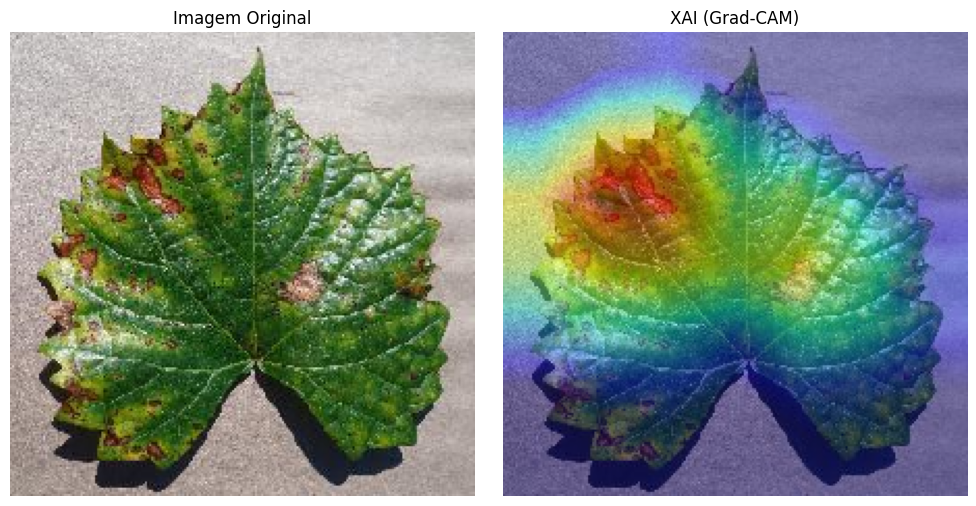

In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Obter imagem e índice da classe
x_batch, y_batch = next(validation_generator)
img_array = x_batch[0]
img_input = np.expand_dims(img_array, axis=0)
class_idx = np.argmax(y_batch[0])

# 2. Localizar camada alvo dentro do base_model
base_model = model.layers[0]
target_layer = base_model.get_layer("top_conv")

# 3. ✅ SOLUÇÃO: criar um Input novo e conectar os grafos manualmente
new_input = tf.keras.Input(shape=(224, 224, 3))

# Modelo interno: base_model.input → [conv_output, base_model.output]
internal_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[target_layer.output, base_model.output]
)

# Chamar internal_model sobre o novo input (conecta os grafos)
conv_tensor, base_out_tensor = internal_model(new_input)

# Aplicar as camadas restantes do modelo externo (após base_model)
x = base_out_tensor
for layer in model.layers[1:]:
    x = layer(x)

# Modelo combinado: novo input → [conv_features, predições finais]
grad_model = tf.keras.Model(inputs=new_input, outputs=[conv_tensor, x])

# 4. Computar Grad-CAM
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_input)
    loss = predictions[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

# 5. Calcular pesos e mapa de ativação
output = conv_outputs[0]
grads_val = grads[0]
weights = tf.reduce_mean(grads_val, axis=(0, 1))
cam = np.zeros(output.shape[0:2], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * output[:, :, i]

# 6. Pós-processamento
cam = cv2.resize(cam.numpy(), (224, 224))
cam = np.maximum(cam, 0)
heatmap = (cam - cam.min()) / (cam.max() - cam.min() + 1e-10)

# 7. Visualização
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagem Original")
plt.imshow(img_array)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("XAI (Grad-CAM)")
plt.imshow(img_array)
plt.imshow(heatmap, cmap='jet', alpha=0.4)
plt.axis('off')

plt.tight_layout()
plt.savefig("resultado_xai_final_sucesso.png")
plt.show()

In [14]:
# Avaliação no conjunto de validação reduzido
results = model.evaluate(validation_generator)
print(f"Loss: {results[0]}")
print(f"Acurácia: {results[1]}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 58s 106ms/step - accuracy: 0.2769 - loss: 4.6370
Loss: 4.636973857879639
Acurácia: 0.27686092257499695
